# Buenos Aires Household Survey

## Academic Companion Notebook

This notebook is the academic-facing companion to the portfolio version of the project. It does not rerun the full pipeline from raw survey data. Instead, it reads the validated outputs exported by [`scripts/household_analysis.py`](scripts/household_analysis.py) and organizes them in a more academic structure.

### Abstract

This project studies inequality in the 2019 Annual Household Survey for Buenos Aires City. The analytical purpose is to connect territorial inequality, educational attainment, labor-market rewards, household composition, and gender differences inside a single urban dataset. The current version moves beyond exploratory analysis by combining non-parametric hypothesis tests, a semilog Mincer earnings equation, Oaxaca-Blinder decomposition with bootstrap inference, and machine-learning benchmarks with cross-validation.

### Core claim

The project supports a layered interpretation of inequality. Income differences in Buenos Aires are not explained by a single mechanism. They emerge through the interaction of commune-level stratification, schooling differentials, household dilution of resources, and a gender gap that remains large after controlling for observable characteristics.


In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

BASE_DIR = Path.cwd()
required_paths = [
    BASE_DIR / 'outputs/tables/commune_income_summary.csv',
    BASE_DIR / 'outputs/tables/statistical_tests.csv',
    BASE_DIR / 'outputs/tables/mincer_coefficients.csv',
    BASE_DIR / 'outputs/tables/mincer_diagnostics.csv',
    BASE_DIR / 'outputs/tables/mincer_vif.csv',
    BASE_DIR / 'outputs/tables/oaxaca_bootstrap_summary.csv',
    BASE_DIR / 'outputs/tables/ml_model_comparison.csv',
    BASE_DIR / 'outputs/tables/ml_cross_validation.csv',
]
missing = [str(path.relative_to(BASE_DIR)) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing expected outputs: {missing}')
print('All required outputs are available.')


All required outputs are available.


In [2]:
commune_summary = pd.read_csv(BASE_DIR / 'outputs/tables/commune_income_summary.csv')
education_summary = pd.read_csv(BASE_DIR / 'outputs/tables/education_income_summary.csv')
statistical_tests = pd.read_csv(BASE_DIR / 'outputs/tables/statistical_tests.csv')
mincer = pd.read_csv(BASE_DIR / 'outputs/tables/mincer_coefficients.csv')
diagnostics = pd.read_csv(BASE_DIR / 'outputs/tables/mincer_diagnostics.csv')
vif = pd.read_csv(BASE_DIR / 'outputs/tables/mincer_vif.csv')
oaxaca = pd.read_csv(BASE_DIR / 'outputs/tables/oaxaca_bootstrap_summary.csv')
ml_models = pd.read_csv(BASE_DIR / 'outputs/tables/ml_model_comparison.csv')
ml_cv = pd.read_csv(BASE_DIR / 'outputs/tables/ml_cross_validation.csv')
ml_features = pd.read_csv(BASE_DIR / 'outputs/tables/ml_feature_importance.csv')

schooling_premium = float(mincer.loc[mincer['term'] == 'anos_escolaridad', 'approx_pct_effect'].iloc[0])
unexplained_gap = float(oaxaca.loc[oaxaca['component'] == 'Unexplained effect', 'mean_pct_gap'].iloc[0])
cv_best = ml_cv.iloc[0]

summary = pd.DataFrame([
    {'metric': 'Households', 'value': '5,848'},
    {'metric': 'Workers in labor model', 'value': '6,656'},
    {'metric': 'Schooling premium', 'value': f'{schooling_premium:.2f}%'},
    {'metric': 'Bootstrap unexplained gender gap', 'value': f'{unexplained_gap:.2f}%'},
    {'metric': 'Best cross-validated ML model', 'value': f"{cv_best['model']} (R^2={cv_best['cv_r2_mean']:.3f})"},
])
summary


,metric,value
0,Households,"5,848"
1,Workers in labor model,"6,656"
2,Schooling premium,13.25%
3,Bootstrap unexplained gender gap,40.18%
4,Best cross-validated ML model,Gradient Boosting (R^2=0.346)


## 1. Data architecture and theoretical framing

The Annual Household Survey is useful because it captures demographics, education, labor outcomes, and territorial information inside the same urban setting. That allows the project to move across levels of analysis.

- The **household layer** is needed because welfare is experienced at the household level rather than only through individual pay.
- The **individual labor-income layer** is needed because the return to schooling is most naturally interpreted through an earnings equation.
- The **decomposition layer** is needed because the gender gap question is not only whether a gap exists, but whether it is explained by observed characteristics.

This sequencing preserves the strongest part of the original academic delivery: the idea that the dataset is analytically valuable because it can connect social structure with labor-market outcomes.


In [3]:
display(Markdown('### Commune and education summaries'))
display(commune_summary.head(8))
display(education_summary.head(8))


### Commune and education summaries

,commune,households,median_household_income,median_per_capita_income,average_members
0,14,394,70000.0,37000.0,2.149746
1,13,380,65500.0,32583.5,2.192105
2,2,385,60000.0,35000.0,1.987013
3,6,346,60000.0,31000.0,2.182081
4,12,326,56450.0,28600.0,2.457055
5,15,339,51000.0,25000.0,2.398230
6,10,328,50000.0,24750.0,2.332317
7,11,311,50000.0,24250.0,2.340836


,education_level,people,median_total_income,average_total_income
0,General secondary,3672,43000.0,54176.359477
1,Other special schools,2570,23000.0,28384.871206
2,Special primary,2194,20000.0,23738.250684
3,General primary,939,15000.0,18991.961661
4,EGB (1° a 9° año),1516,13000.0,17101.443272
5,Kindergarten age 5,290,12550.0,15401.696552
6,Unspecified,46,8900.0,13973.913043
7,Not applicable,34,7000.0,6611.764706


## 2. Hypothesis testing before modeling

The current version strengthens the descriptive layer by testing whether the headline patterns are statistically credible. This is important because it prevents the later econometric work from feeling detached from the data.

The tests address four questions:

1. Do household-income distributions differ across communes?
2. Is household size systematically associated with per-capita income?
3. Do education groups show distinct income distributions?
4. Do male and female workers differ in labor-income distributions before controls?


In [4]:
statistical_tests[['test_id', 'question', 'test', 'statistic', 'p_value', 'key_signal']]


,test_id,question,test,statistic,p_value,key_signal
0,T1,Do household-income distributions differ acros...,Kruskal-Wallis,3.808574e+02,1.357581e-72,Reject equal medians across communes; geograph...
1,T2,Is household size monotonically associated wit...,Spearman correlation,-3.882291e-01,1.101452e-209,Larger households are associated with lower pe...
2,T3,Do education groups show different individual ...,Kruskal-Wallis,2.360935e+03,0.000000e+00,Income rises meaningfully across schooling cat...
3,T4,Do men and women show different labor-income d...,Mann-Whitney U,6.355921e+06,1.263248e-25,The raw gender gap is visible even before cond...


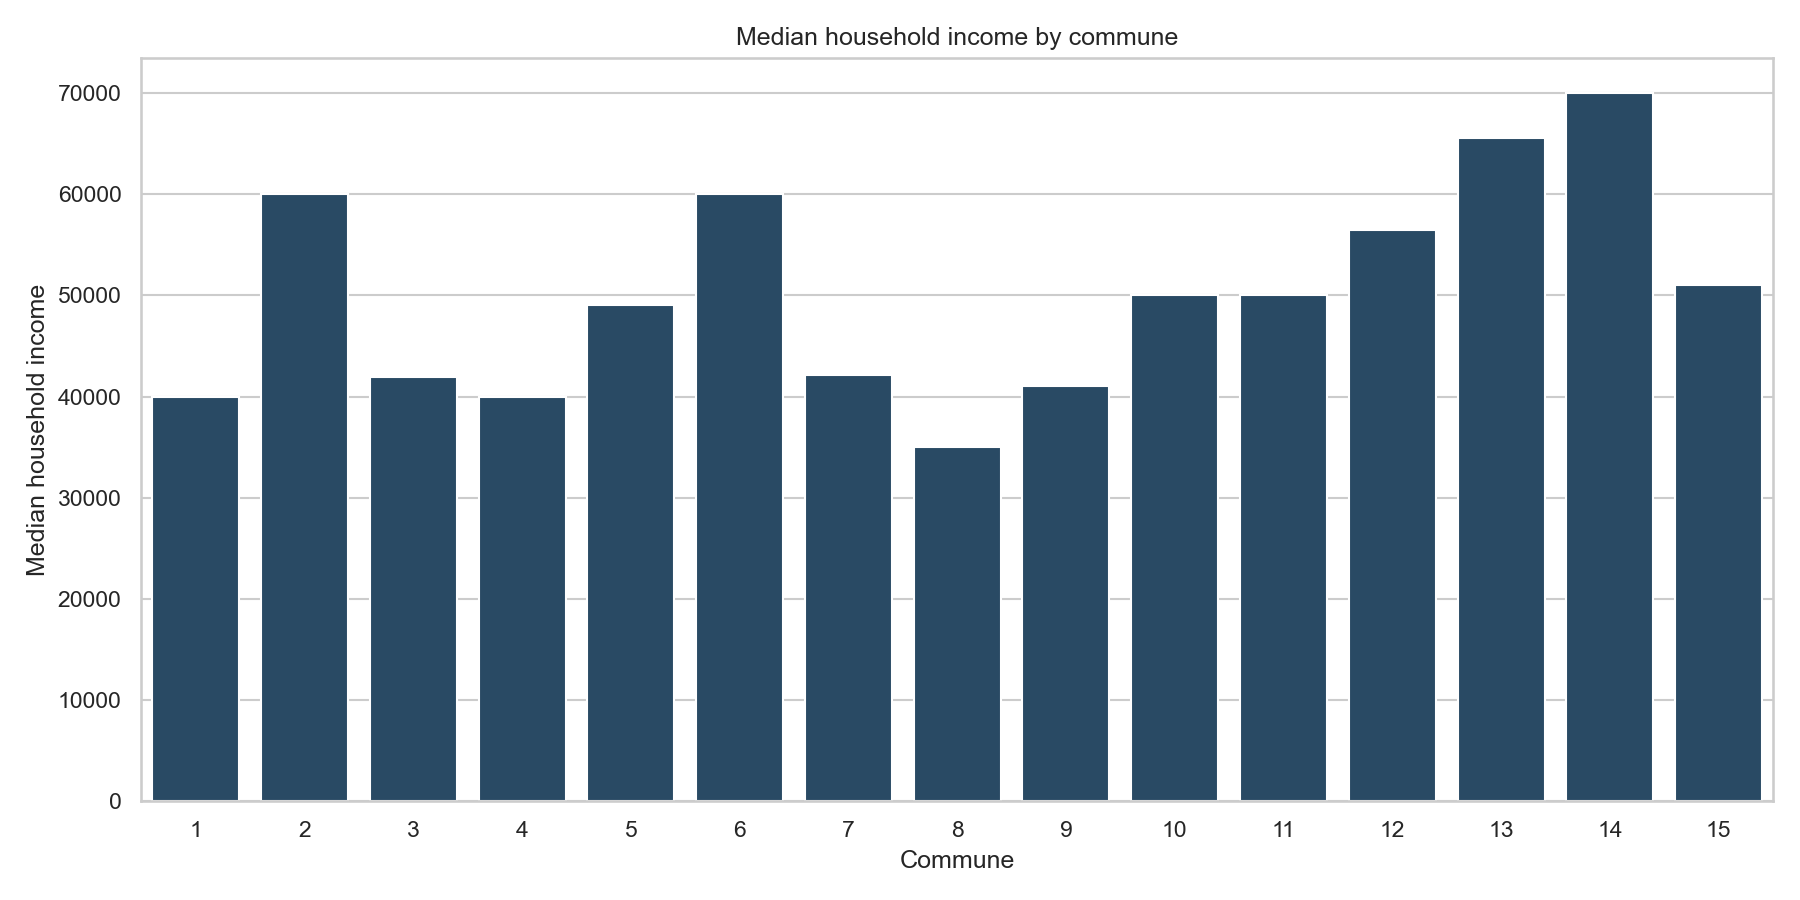

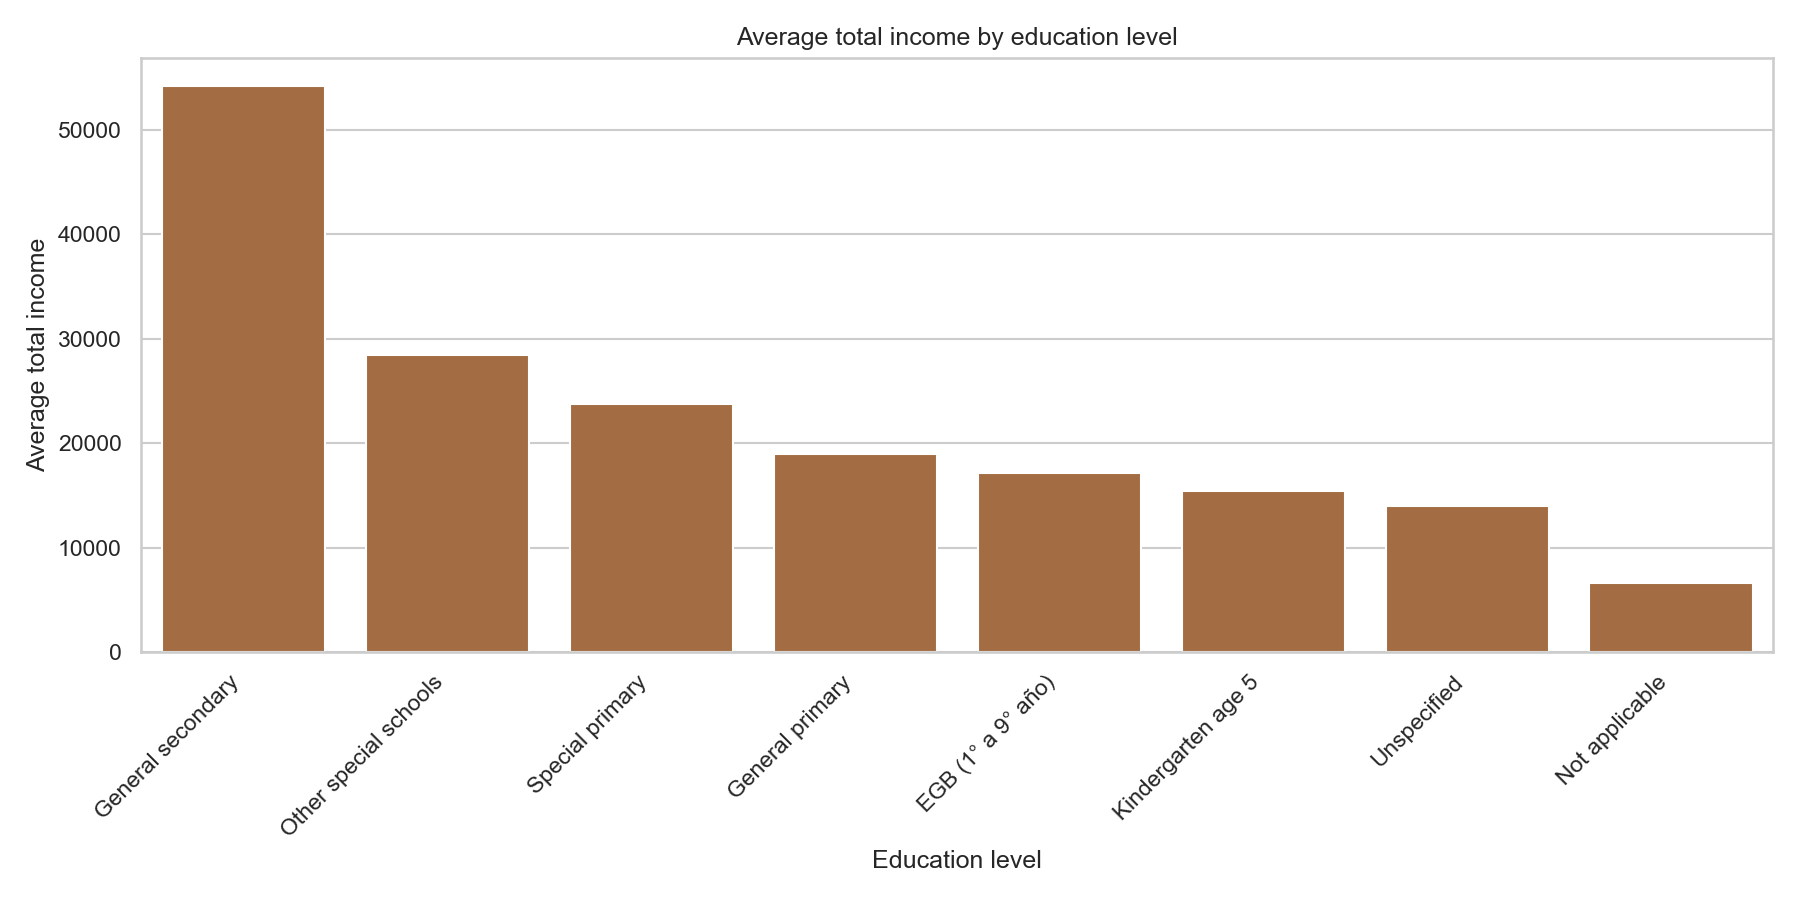

In [5]:
for figure_path in [
    BASE_DIR / 'outputs/figures/median_household_income_by_commune.png',
    BASE_DIR / 'outputs/figures/average_income_by_education.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 3. Mincer equation and diagnostic discipline

The earnings model is a semilog Mincer specification with schooling, centered potential experience, occupation, commune, and gender. Centering the experience polynomial matters because it dramatically reduces multicollinearity in the nonlinear term while preserving the concave age-earnings profile that theory expects.

The diagnostics also matter:

- **Breusch-Pagan** rejects homoskedasticity, so robust `HC3` standard errors are appropriate.
- **RESET** does not suggest that a broad omitted nonlinearity remains after centering experience.
- **Jarque-Bera** rejects residual normality, which is common in earnings data and reinforces the use of robust inference.
- **VIF values** around `1.01` to `1.15` show that the centered polynomial is numerically stable.


In [6]:
display(Markdown('### Core Mincer coefficients'))
display(mincer)
display(Markdown('### Model diagnostics'))
display(diagnostics)
display(Markdown('### Variance inflation factors'))
display(vif)


### Core Mincer coefficients

,term,label,coefficient,std_error,p_value,approx_pct_effect
0,anos_escolaridad,Additional year of schooling,0.124413,0.003033,0.000000e+00,13.248314
1,experience_centered,Potential experience (centered),0.015121,0.000772,2.180927e-85,1.523566
2,I(experience_centered ** 2),Potential experience squared,-0.000496,0.000061,6.631532e-16,-0.049546
3,C(sexo)[T.Varon],Male income premium,0.338234,0.017590,2.109188e-82,40.246841


### Model diagnostics

,diagnostic,statistic,p_value,interpretation
0,Adjusted R-squared,0.377951,NaN,Share of log-income variation explained by the...
1,Breusch-Pagan LM,176.178994,1.638968e-26,Tests for heteroskedasticity in the residual v...
2,Breusch-Pagan F,8.589093,6.591085e-27,F-version of the heteroskedasticity diagnostic.
3,RESET F,0.011751,9.136814e-01,Checks whether important nonlinear patterns re...
4,Jarque-Bera,3663.337808,0.000000e+00,Assesses whether residuals are normally distri...
5,Observations,6656.000000,NaN,Working sample used in the labor-income model.


### Variance inflation factors

,term,vif,interpretation
0,anos_escolaridad,1.146707,Values close to 1 suggest low multicollinearit...
1,experience_centered,1.139100,Values close to 1 suggest low multicollinearit...
2,experience_centered_sq,1.126171,Values close to 1 suggest low multicollinearit...
3,male,1.009969,Values close to 1 suggest low multicollinearit...


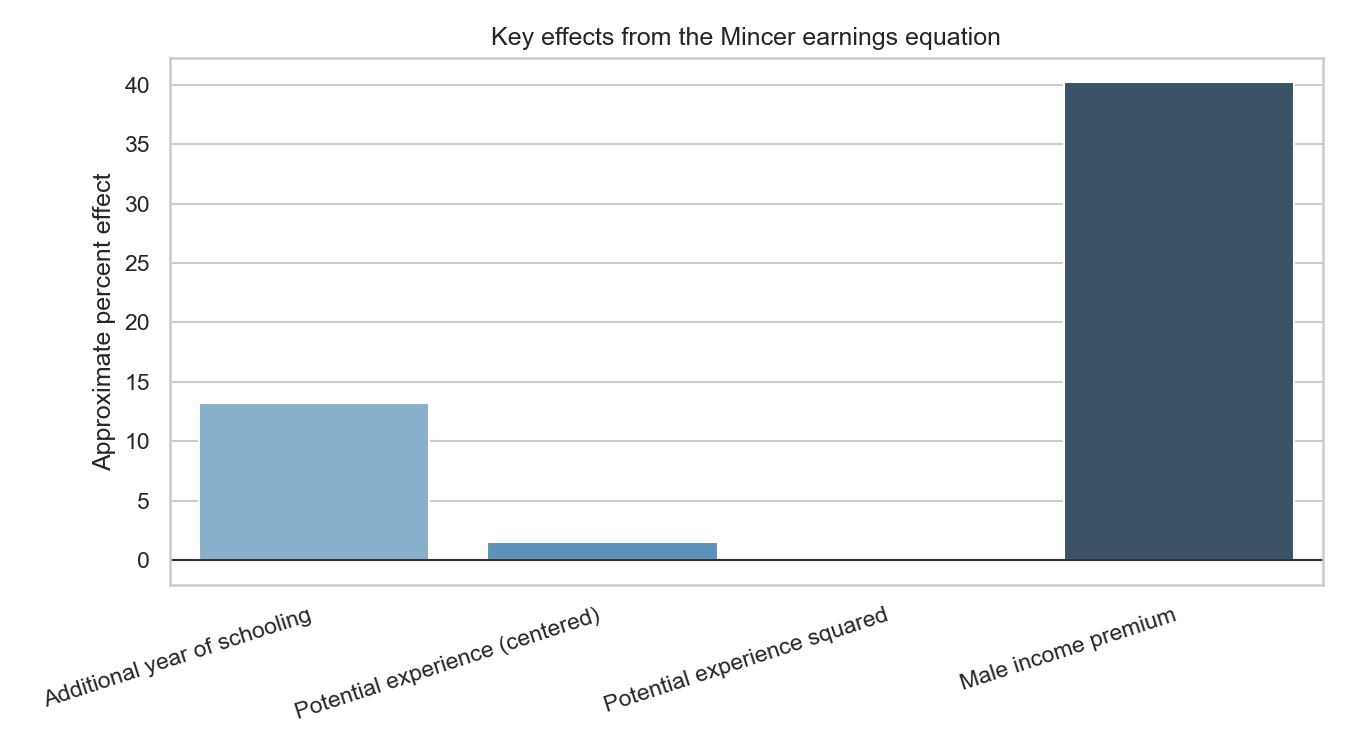

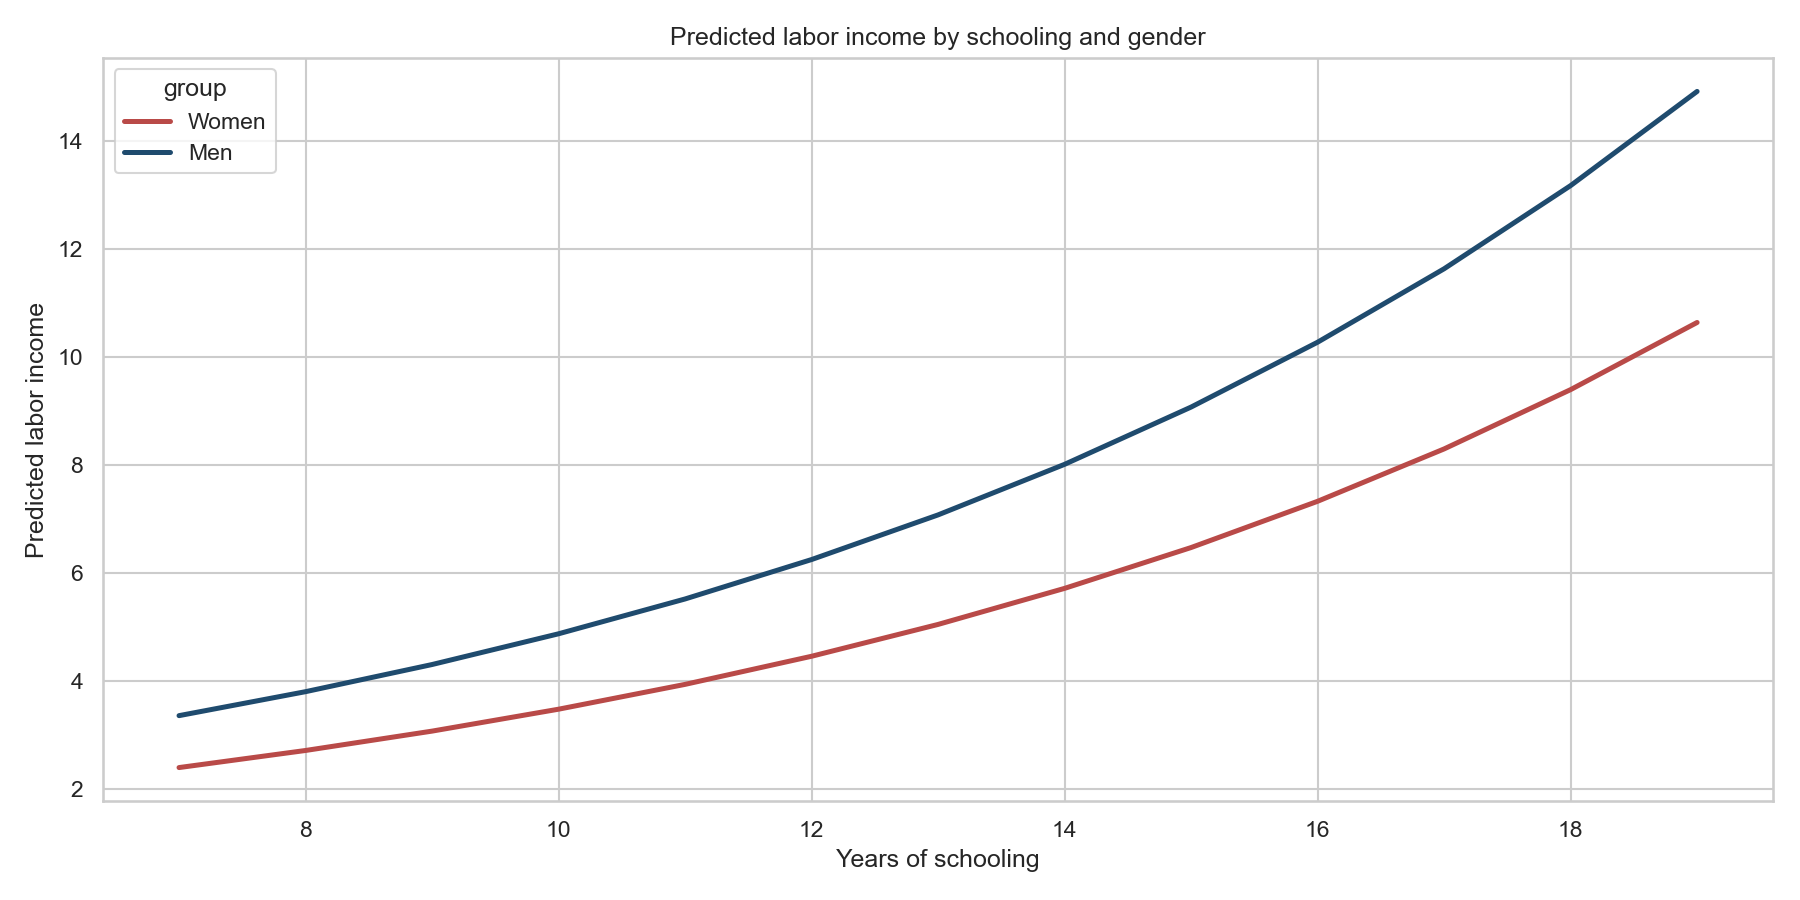

In [7]:
for figure_path in [
    BASE_DIR / 'outputs/figures/mincer_key_effects.png',
    BASE_DIR / 'outputs/figures/predicted_labor_income_by_schooling_gender.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 4. Oaxaca-Blinder decomposition

The decomposition layer addresses a more substantive question than the raw gender gap alone. The core result is that the unexplained component remains large after conditioning on the available controls. In the current bootstrap summary, the unexplained component stays well above zero across the confidence interval, which makes the result analytically important rather than merely descriptive.


In [8]:
oaxaca[['component', 'mean_pct_gap', 'ci_low_pct_gap', 'ci_high_pct_gap', 'successful_iterations']]


,component,mean_pct_gap,ci_low_pct_gap,ci_high_pct_gap,successful_iterations
0,Explained effect,-7.724939,-10.018335,-5.217050,200
1,Total gap,29.355387,23.750918,34.784308,200
2,Unexplained effect,40.184560,35.161122,45.081399,200


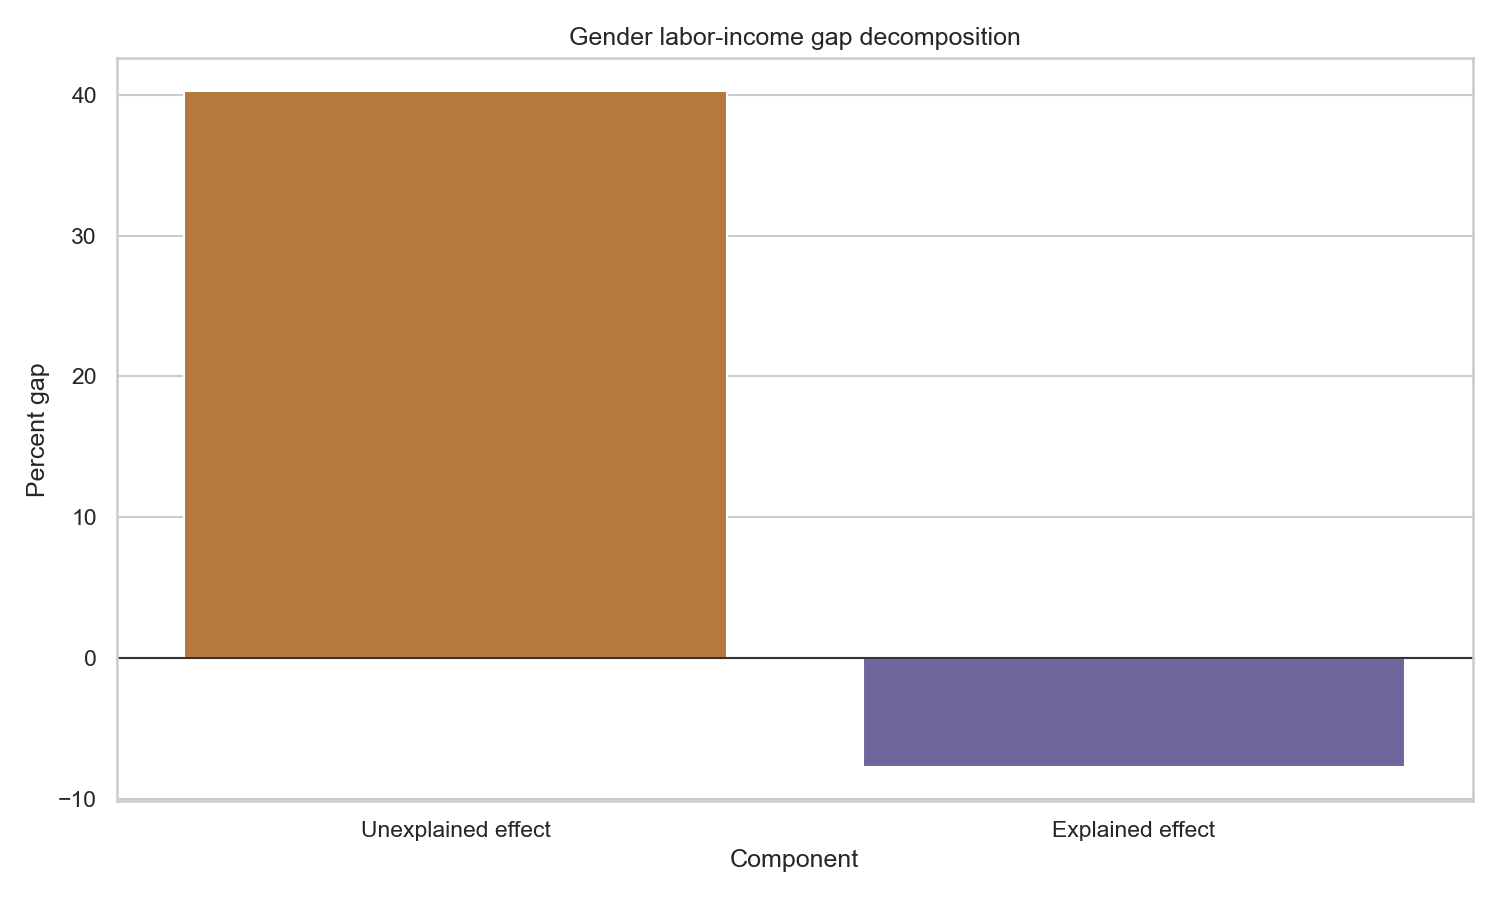

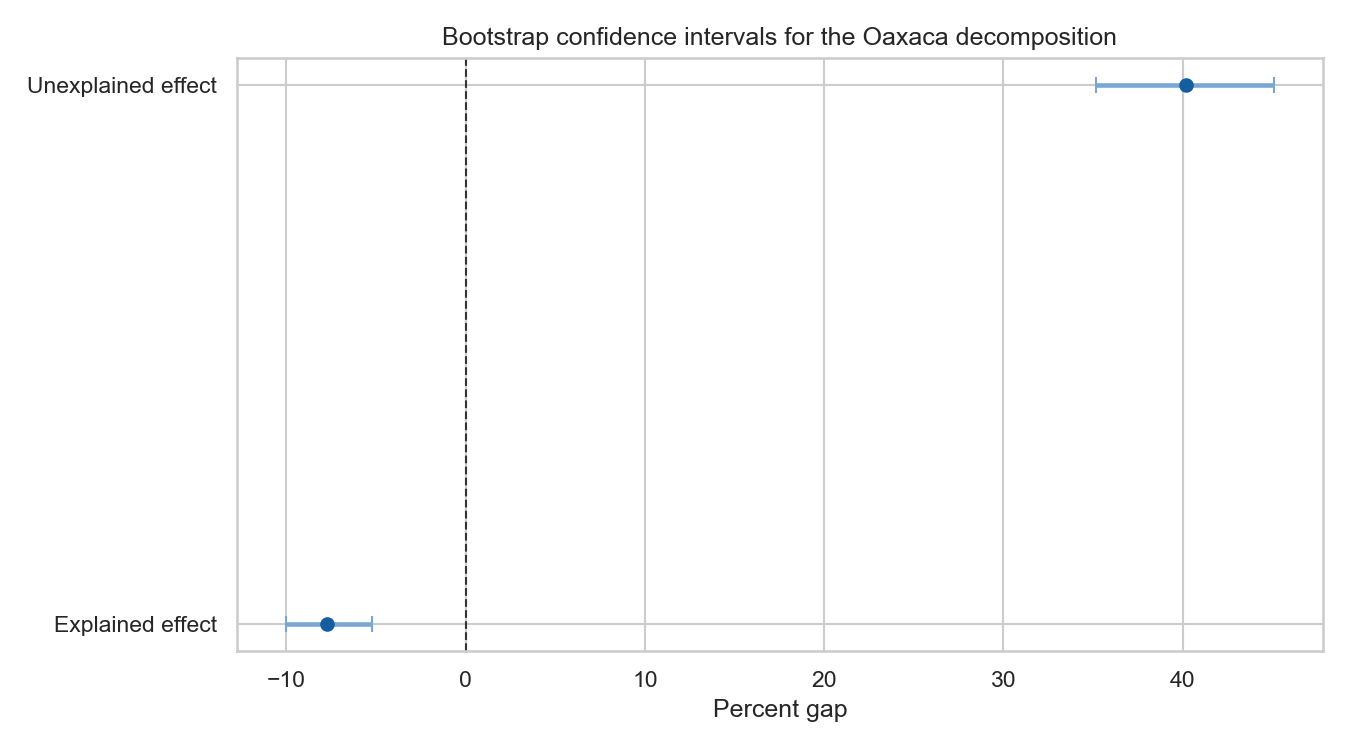

In [9]:
for figure_path in [
    BASE_DIR / 'outputs/figures/gender_income_gap_decomposition.png',
    BASE_DIR / 'outputs/figures/oaxaca_bootstrap_ci.png',
]:
    display(Image(filename=str(figure_path), width=850))


## 5. Machine-learning robustness layer

The ML benchmark is deliberately framed as a robustness exercise. The point is not to replace interpretation with prediction, but to ask whether more flexible models recover substantially more signal than the interpretable baseline.

The answer is: only a little.

- The best holdout model is **Gradient Boosting**.
- The best cross-validated model is also **Gradient Boosting**.
- The linear benchmark remains close in cross-validated performance.

This is analytically useful because it suggests that the interpretable structure already captures most of the economically meaningful signal.


In [10]:
display(Markdown('### Holdout performance'))
display(ml_models)
display(Markdown('### Cross-validated performance'))
display(ml_cv)
display(Markdown('### Most important feature groups'))
display(ml_features.head(10))


### Holdout performance

,model,mae_log,rmse_log,r2_log,mae_income,rmse_income
0,Gradient Boosting,0.482293,0.655274,0.342132,13136.219013,17897.261460
1,Linear benchmark,0.488249,0.661383,0.329808,13329.861391,18193.652038
2,Elastic Net,0.488783,0.662889,0.326753,13327.805711,18185.608723
3,Random Forest,0.496269,0.671804,0.308522,13490.796070,18164.924344


### Cross-validated performance

,model,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std
0,Gradient Boosting,0.346433,0.020075,0.486649,0.011136,0.664825,0.016077
1,Linear benchmark,0.339029,0.020713,0.491421,0.009207,0.668566,0.015866
2,Elastic Net,0.337826,0.022545,0.491584,0.008917,0.669138,0.015506
3,Random Forest,0.312699,0.032530,0.500049,0.009123,0.681479,0.012824


### Most important feature groups

,feature_group,importance
0,anos_escolaridad,0.471361
1,edad,0.134408
2,cat_ocupacional,0.117313
3,sexo,0.077673
4,comuna,0.065674
5,children_count,0.051474
6,potential_experience,0.029493
7,situacion_conyugal,0.026581
8,nivel_max_educativo,0.026024


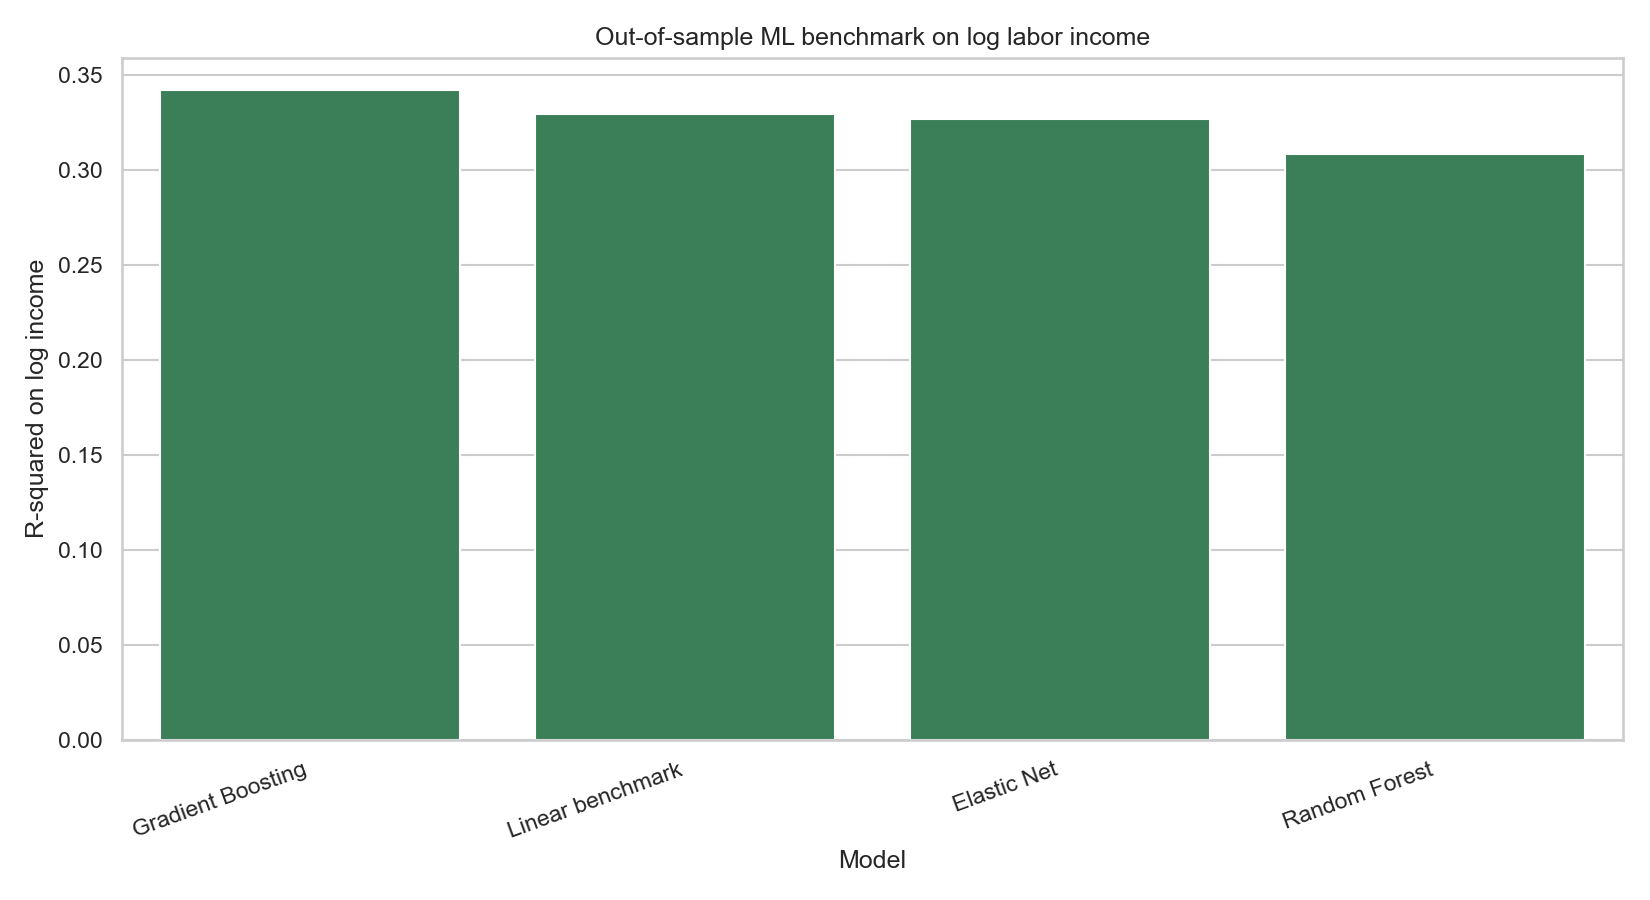

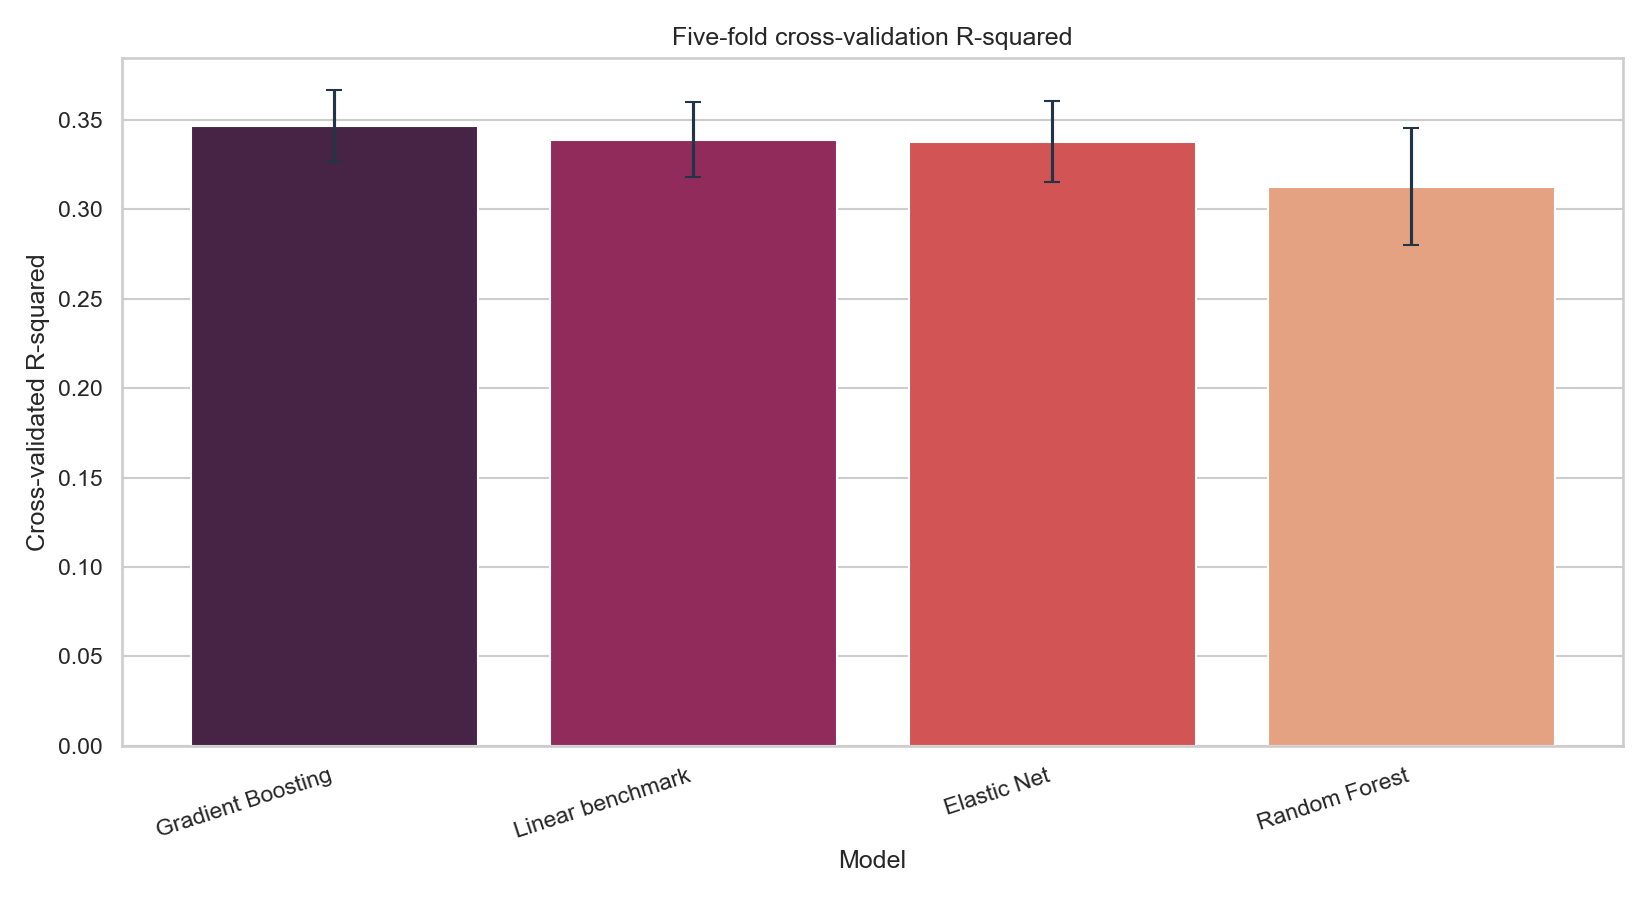

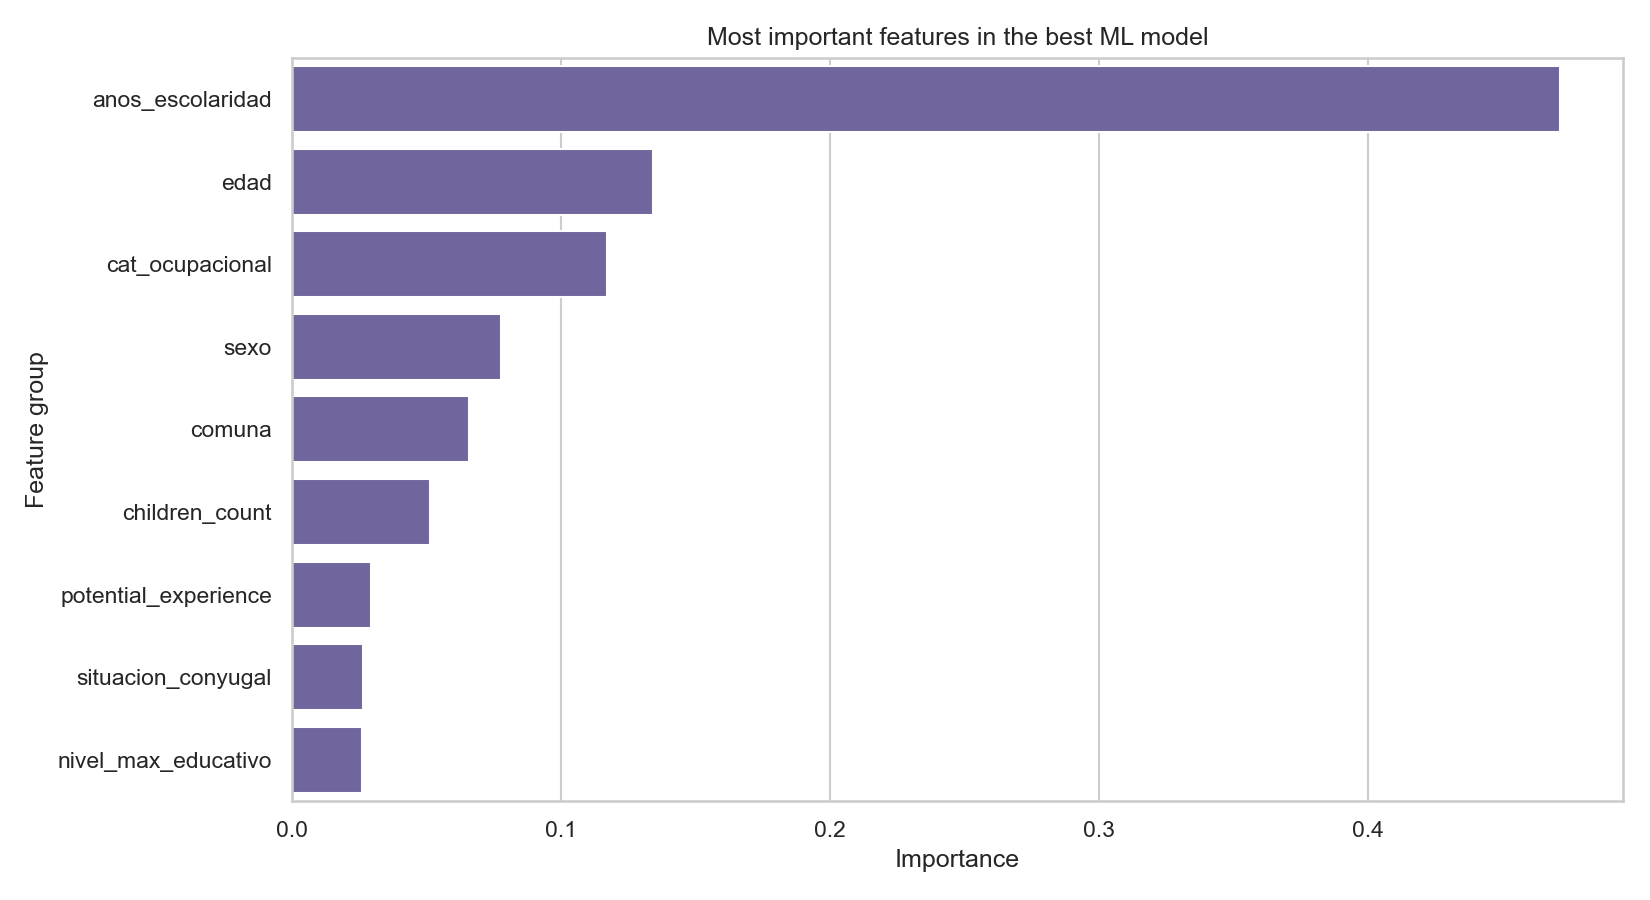

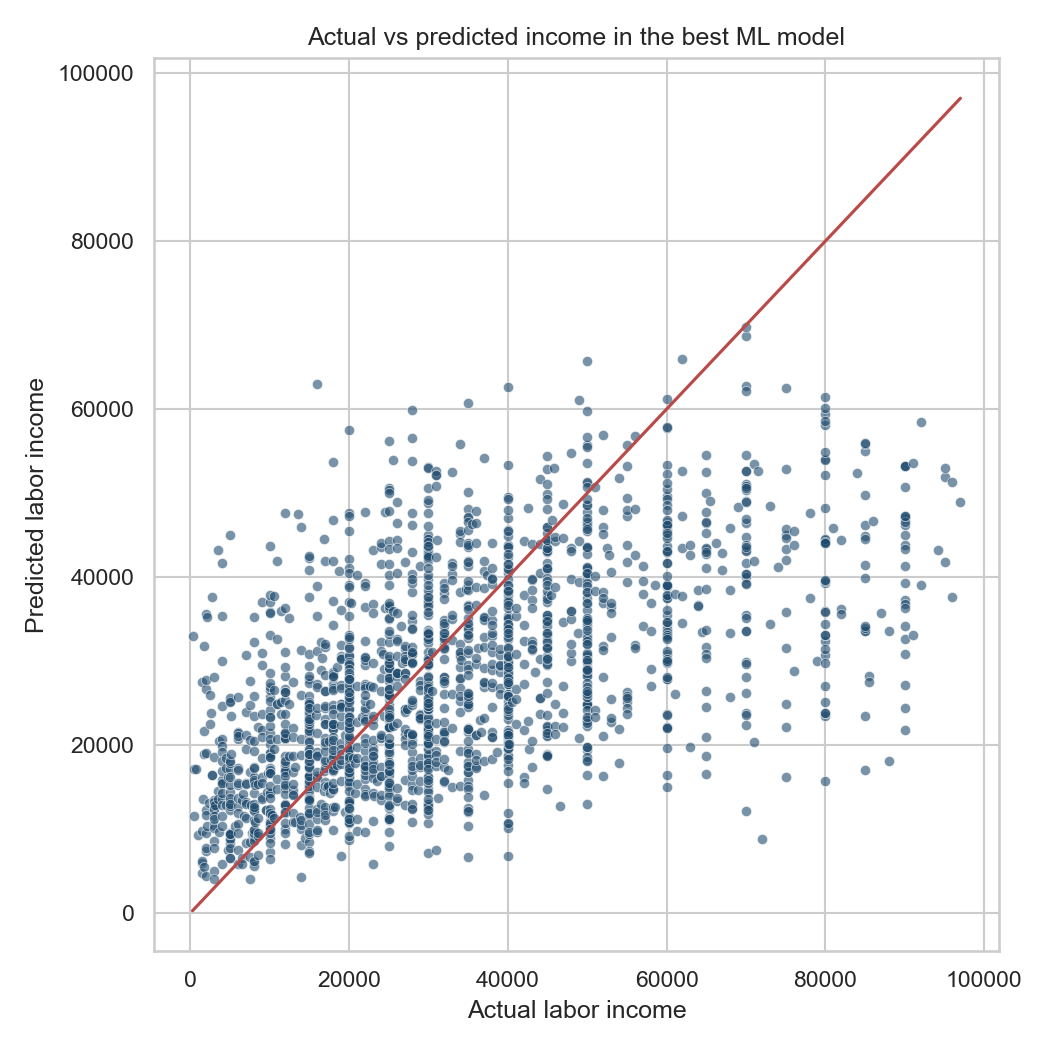

In [11]:
for figure_path in [
    BASE_DIR / 'outputs/figures/ml_model_performance.png',
    BASE_DIR / 'outputs/figures/ml_cross_validation_r2.png',
    BASE_DIR / 'outputs/figures/ml_feature_importance.png',
    BASE_DIR / 'outputs/figures/ml_actual_vs_predicted.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 6. Conclusion

The project now supports a stronger academic statement than the original descriptive notebook alone. Income inequality in Buenos Aires is structured simultaneously by territory, schooling, household size, and gender. The econometric layer formalizes those mechanisms, the decomposition layer shows that observed controls do not exhaust the gender gap, and the ML layer confirms that added flexibility improves fit only modestly.

That is a strong result because it combines explanation, diagnostics, and disciplined benchmarking in a single urban microdata case.
